Saving Copy of Online Retail.csv to Copy of Online Retail (1).csv
Dataset Loaded Successfully

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

        InvoiceDate  UnitPrice  CustomerID         Country  
0  01-12-2010 08:26       2.55     17850.0  United Kingdom  
1  01-12-2010 08:26       3.39     17850.0  United Kingdom  
2  01-12-2010 08:26       2.75     17850.0  United Kingdom  
3  01-12-2010 08:26       3.39     17850.0  United Kingdom  
4  01-12-2010 08:26       3.39     17850.0  United Kingdom  

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns

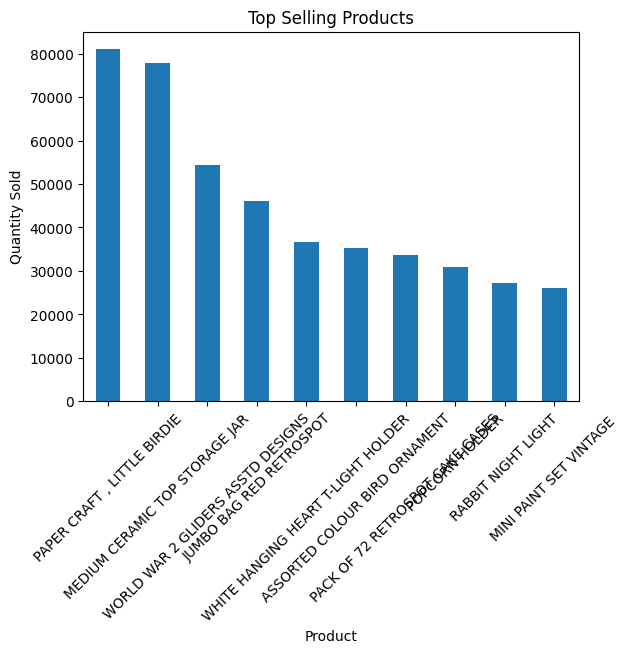

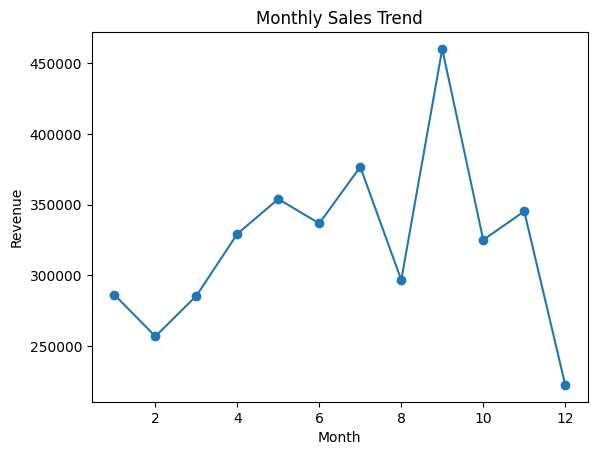

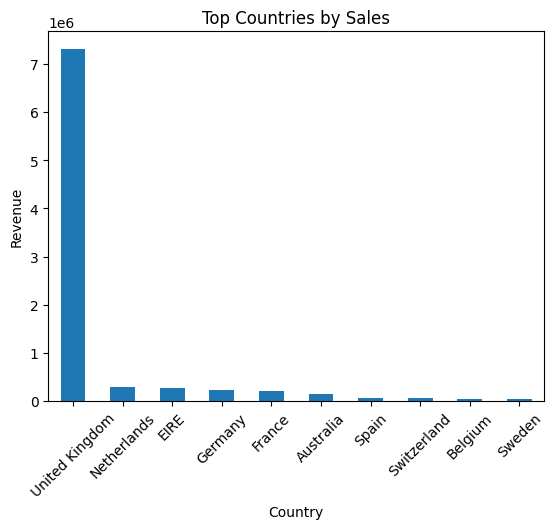

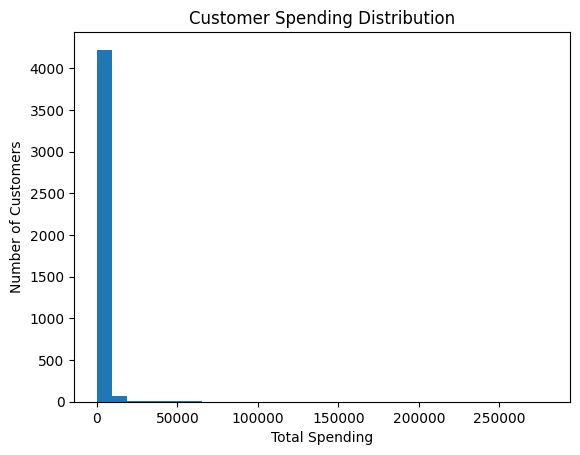


FINAL INSIGHTS:
Top products generate maximum sales
Monthly trends show seasonal variation
Few customers contribute high revenue
Sales vary across different countries

PROJECT COMPLETED SUCCESSFULLY


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from google.colab import files
uploaded = files.upload()


file_name = list(uploaded.keys())[0]

if file_name.endswith('.xlsx'):
    df = pd.read_excel(file_name)
else:
    df = pd.read_csv(file_name, encoding='latin1')


print("Dataset Loaded Successfully\n")
print(df.head())


print("\nDataset Info:\n")
df.info()

print("\nMissing Values:\n")
print(df.isnull().sum())



df.dropna(inplace=True)

df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

print("\nData after cleaning:", df.shape)



df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day



price_array = df['TotalPrice'].values

print("\nNumPy Statistics:")
print("Mean:", np.mean(price_array))
print("Max:", np.max(price_array))
print("Min:", np.min(price_array))



top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

monthly_sales = df.groupby('Month')['TotalPrice'].sum()

country_sales = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

customer_spending = df.groupby('CustomerID')['TotalPrice'].sum()



sorted_data = df.sort_values(by='TotalPrice', ascending=False)

sample_data = df.iloc[:5]

print("\nSample Data:\n")
print(sample_data)



high_value = customer_spending[customer_spending > 1000]
low_value = customer_spending[customer_spending <= 1000]

print("\nHigh Value Customers:", len(high_value))
print("Low Value Customers:", len(low_value))



plt.figure()
top_products.plot(kind='bar')
plt.title("Top Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.show()


plt.figure()
monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()


plt.figure()
country_sales.plot(kind='bar')
plt.title("Top Countries by Sales")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()


plt.figure()
customer_spending.plot(kind='hist', bins=30)
plt.title("Customer Spending Distribution")
plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")
plt.show()



print("\nFINAL INSIGHTS:")
print("Top products generate maximum sales")
print("Monthly trends show seasonal variation")
print("Few customers contribute high revenue")
print("Sales vary across different countries")

print("\nPROJECT COMPLETED SUCCESSFULLY")